In [1]:
# GPU availability check
import torch
import sys

print("Python version:", sys.version)
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("CUDA version:", torch.version.cuda)
    print("Number of GPUs:", torch.cuda.device_count())
    for i in range(torch.cuda.device_count()):
        print(f"GPU {i}: {torch.cuda.get_device_name(i)}")
        print(f"  Memory: {torch.cuda.get_device_properties(i).total_memory / 1024**3:.1f} GB")
    print("Current device:", torch.cuda.current_device())
    print("Device name:", torch.cuda.get_device_name())
else:
    print("CUDA is not available")
    print("Available devices:", "CPU only")

Python version: 3.9.22 | packaged by conda-forge | (main, Apr 14 2025, 23:35:59) 
[GCC 13.3.0]
PyTorch version: 2.5.1
CUDA available: True
CUDA version: 12.1
Number of GPUs: 1
GPU 0: NVIDIA RTX 6000 Ada Generation
  Memory: 47.4 GB
Current device: 0
Device name: NVIDIA RTX 6000 Ada Generation


# UMAP Visualization Script for PBMC68k Soft Dataset

This script analyzes the generated samples from the pbmc68k_soft model.
- Loads the generated gene expression data directly (no autoencoder decoding needed)
- Creates UMAP visualizations comparing real vs generated cells
- Performs basic quality checks and correlation analysis

In [2]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import sys
import warnings
warnings.filterwarnings('ignore')

# Set up scanpy settings
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=80, facecolor='white')

print("Environment set up successfully!")

Environment set up successfully!


## Load Real Data

In [3]:
# Load PBMC68k dataset and apply same preprocessing as in cell_train_soft.py
adata = sc.read_h5ad('/home/suzuki/Projects/scDiffusion/data_preparation/pbmc68k.h5ad')

print(f"Original data shape: {adata.shape}")

# Apply the same preprocessing as in cell_train_soft.py to match gene filtering
print("Applying preprocessing to match soft model training...")
sc.pp.filter_genes(adata, min_cells=3)
sc.pp.filter_cells(adata, min_genes=10)
adata.var_names_make_unique()

print(f"Data shape after filtering: {adata.shape}")
print(f"Available obs columns: {list(adata.obs.columns)}")

Original data shape: (68579, 32738)
Applying preprocessing to match soft model training...
filtered out 14949 genes that are detected in less than 3 cells
Data shape after filtering: (68579, 17789)
Available obs columns: ['TSNE.1', 'TSNE.2', 'celltype', 'n_genes']
Data shape after filtering: (68579, 17789)
Available obs columns: ['TSNE.1', 'TSNE.2', 'celltype', 'n_genes']


## Prepare Real Data for Analysis

In [4]:
# Find cell type column and prepare labels
if 'celltype' in adata.obs.columns:
    cell_type_col = 'celltype'
elif 'cell_type' in adata.obs.columns:
    cell_type_col = 'cell_type'
else:
    print("Available columns:", list(adata.obs.columns))
    cell_type_col = None

if cell_type_col:
    print(f"Using cell type column: {cell_type_col}")
    print(f"Cell types: {list(adata.obs[cell_type_col].unique())}")
    celltype = adata.obs[cell_type_col]
else:
    print("Warning: No cell type column found")
    celltype = None

# Apply the same normalization as in training pipeline
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Get gene expression data (already log-normalized)
if hasattr(adata.X, 'toarray'):
    cell_data = adata.X.toarray()
else:
    cell_data = adata.X

print(f"Cell data shape: {cell_data.shape}")
print(f"Gene names: {len(adata.var_names)} genes")

# Store gene names for later use
gene_names = adata.var_names.tolist()

Using cell type column: celltype
Cell types: ['CD8+ Cytotoxic T', 'CD8+/CD45RA+ Naive Cytotoxic', 'CD4+/CD45RO+ Memory', 'CD19+ B', 'CD4+/CD25 T Reg', 'CD56+ NK', 'CD4+ T Helper2', 'CD4+/CD45RA+/CD25- Naive T', 'CD34+', 'Dendritic', 'CD14+ Monocyte']
normalizing counts per cell


    finished (0:00:00)
Cell data shape: (68579, 17789)
Gene names: 17789 genes
Cell data shape: (68579, 17789)
Gene names: 17789 genes


In [5]:
from sklearn.preprocessing import LabelEncoder

# Prepare cell type labels
print('Data shape:', adata.shape)
print('Cell types in dataset:')
print(adata.obs['celltype'].value_counts())

# Encode cell types
classes = adata.obs['celltype'].values
label_encoder = LabelEncoder()
labels = classes
label_encoder.fit(labels)
classes_encoded = label_encoder.transform(labels)

print(f'\nTotal unique cell types: {len(np.unique(labels))}')
print(f'Encoded labels range: {classes_encoded.min()} to {classes_encoded.max()}')

Data shape: (68579, 17789)
Cell types in dataset:
celltype
CD8+ Cytotoxic T                20773
CD8+/CD45RA+ Naive Cytotoxic    16666
CD56+ NK                         8776
CD4+/CD25 T Reg                  6187
CD19+ B                          5908
CD4+/CD45RO+ Memory              3061
CD14+ Monocyte                   2862
Dendritic                        2099
CD4+/CD45RA+/CD25- Naive T       1873
CD34+                             277
CD4+ T Helper2                     97
Name: count, dtype: int64

Total unique cell types: 11
Encoded labels range: 0 to 10


## Load Generated Data from Soft Model

In [6]:
# Load generated samples from soft model
unconditional_path = '/home/suzuki/Projects/scDiffusion/output/simulated_samples/pbmc68k_soft.npz'

print("Loading generated samples from soft model...")
cell_gen = None

try:
    npzfile = np.load(unconditional_path, allow_pickle=True)
    print(f"Available keys in file: {list(npzfile.keys())}")

    # Load generated data
    if 'cell_gen' in npzfile.keys():
        cell_gen = npzfile['cell_gen'][:3000]  # Use 3000 samples
        print("Using 'cell_gen' key")
    elif 'arr_0' in npzfile.keys():
        cell_gen = npzfile['arr_0'][:3000]
        print("Using 'arr_0' key")
    else:
        key = list(npzfile.keys())[0]
        cell_gen = npzfile[key][:3000]
        print(f"Using key: {key}")

    print(f"Loaded generated samples shape: {cell_gen.shape}")
    print("Note: Samples are already in gene expression space")
    
    # Apply log normalization to match real data scale
    if cell_gen is not None:
        print(f"Before log normalization - min={cell_gen.min():.3f}, max={cell_gen.max():.3f}, mean={cell_gen.mean():.3f}")
        
        # Ensure non-negative values before log transformation
        cell_gen = np.maximum(cell_gen, 0)  # Clip negative values to 0
        
        # Apply log(1 + x) transformation to match real data processing
        cell_gen = np.log1p(cell_gen)
        
        print(f"After log normalization - min={cell_gen.min():.3f}, max={cell_gen.max():.3f}, mean={cell_gen.mean():.3f}")
        print(f"Final generated samples shape: {cell_gen.shape}")
    else:
        print("Failed to load generated samples")
        
except FileNotFoundError:
    print(f"Generated samples file not found at: {unconditional_path}")
    print("Please check if the pbmc68k_soft.npz file exists")
except Exception as e:
    print(f"Error loading generated samples: {e}")

Loading generated samples from soft model...
Available keys in file: ['cell_gen']


Using 'cell_gen' key
Loaded generated samples shape: (3000, 17789)
Note: Samples are already in gene expression space
Before log normalization - min=-1281.014, max=1229.205, mean=0.021
After log normalization - min=0.000, max=7.115, mean=2.368
Final generated samples shape: (3000, 17789)


## Gene Expression Correlation Analysis

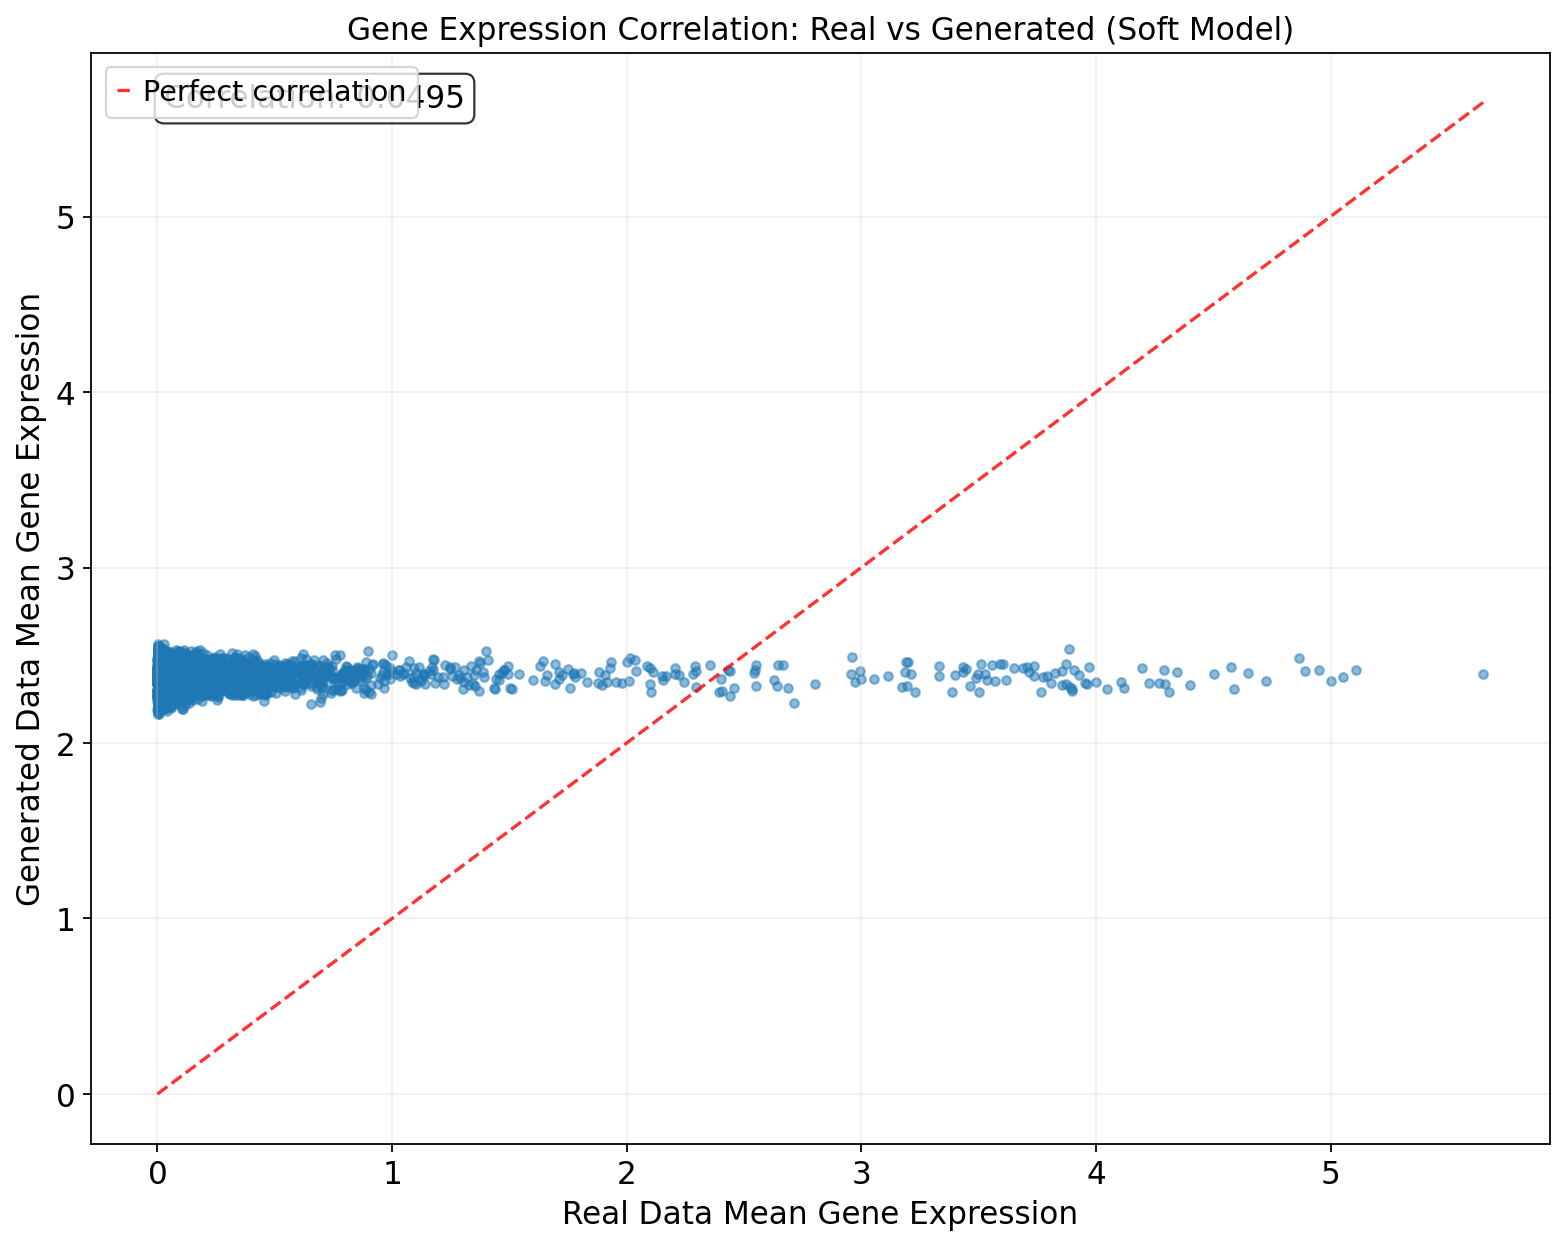

Soft model generation correlation: 0.0495


In [7]:
# Analyze gene expression correlation between real and generated data
if cell_gen is not None:
    # Calculate mean expression per gene
    real_gene_means = cell_data.mean(axis=0)
    gen_gene_means = cell_gen.mean(axis=0)
    
    # Plot correlation
    plt.figure(figsize=(10, 8))
    plt.scatter(real_gene_means, gen_gene_means, alpha=0.5, s=15)
    plt.xlabel('Real Data Mean Gene Expression')
    plt.ylabel('Generated Data Mean Gene Expression')
    plt.title('Gene Expression Correlation: Real vs Generated (Soft Model)')
    
    # Add diagonal line
    min_val = min(real_gene_means.min(), gen_gene_means.min())
    max_val = max(real_gene_means.max(), gen_gene_means.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8, label='Perfect correlation')
    
    # Calculate correlation
    corr_coef = np.corrcoef(real_gene_means, gen_gene_means)[0, 1]
    plt.text(0.05, 0.95, f'Correlation: {corr_coef:.4f}', transform=plt.gca().transAxes, 
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"Soft model generation correlation: {corr_coef:.4f}")
else:
    print("No generated data available for correlation analysis")

In [8]:
# Create AnnData object for UMAP analysis
print("Creating combined dataset for UMAP analysis...")

if cell_gen is not None:
    # Combine real and generated data
    combined_data = np.concatenate((cell_data, cell_gen), axis=0)
    print(f"Combined data shape: {combined_data.shape}")
    
    # Create cell origin labels
    n_real = cell_data.shape[0]
    n_gen = cell_gen.shape[0]
    cell_origin = ['Real'] * n_real + ['Generated'] * n_gen
    
    # Create AnnData object
    adata_combined = sc.AnnData(X=combined_data)
    adata_combined.obs['cell_origin'] = cell_origin
    
    # Add real cell type information
    real_celltypes = adata.obs['celltype'].values
    all_celltypes = list(real_celltypes) + ['Generated'] * n_gen
    adata_combined.obs['celltype'] = all_celltypes
    
    print(f"AnnData object created: {adata_combined.shape}")
    print(f"Cell origin distribution: {adata_combined.obs['cell_origin'].value_counts()}")
    
else:
    print("Error: Generated data not available")

Creating combined dataset for UMAP analysis...


Combined data shape: (71579, 17789)
AnnData object created: (71579, 17789)
Cell origin distribution: cell_origin
Real         68579
Generated     3000
Name: count, dtype: int64
AnnData object created: (71579, 17789)
Cell origin distribution: cell_origin
Real         68579
Generated     3000
Name: count, dtype: int64


In [9]:
# Run UMAP preprocessing and analysis
print("Running UMAP analysis...")

if 'adata_combined' in locals():
    # Basic preprocessing for UMAP
    print("Scaling data...")
    sc.pp.scale(adata_combined, max_value=10)
    
    print("Running PCA...")
    sc.tl.pca(adata_combined, svd_solver='arpack', n_comps=50)
    
    print("Computing neighbors...")
    sc.pp.neighbors(adata_combined, n_neighbors=15, n_pcs=40)
    
    print("Computing UMAP...")
    sc.tl.umap(adata_combined)
    
    print("UMAP computation completed!")
    print(f"UMAP coordinates shape: {adata_combined.obsm['X_umap'].shape}")
    
else:
    print("Error: Combined data not available")

Running UMAP analysis...
Scaling data...


Running PCA...
computing PCA
    with n_comps=50
    with n_comps=50
    finished (0:01:58)
Computing neighbors...
computing neighbors
    finished (0:01:58)
Computing neighbors...
computing neighbors
    using 'X_pca' with n_pcs = 40
    using 'X_pca' with n_pcs = 40
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:27)
Computing UMAP...
computing UMAP
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:27)
Computing UMAP...
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:37)
UMAP computation completed!
UMAP coordinates shape: (71579, 2)
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:37)
UMAP computation completed!
UMAP coordinates shape: (71579, 2)


## Gene Network Analysis
Gene-gene interaction network comparison between real and generated data

In [31]:
# Gene Network Analysis - Compare real and generated data networks
print("=== GENE NETWORK ANALYSIS ===")

# Import gene network metrics
import sys
sys.path.append('/home/suzuki/Projects/scDiffusion')
from metrics.gene_network_metrics import make_weighted_graph_from_adata, adjacency_correlation

if 'cell_data' in locals() and 'cell_gen' in locals():
    try:
        # Create separate AnnData objects for real and generated data
        print("Creating AnnData objects for network analysis...")
        
        # Create real data AnnData
        adata_real = sc.AnnData(X=cell_data)
        adata_real.var_names = [f"Gene_{i}" for i in range(cell_data.shape[1])]
        print(f"Real data AnnData: {adata_real.shape}")
        
        # Create generated data AnnData  
        adata_gen = sc.AnnData(X=cell_gen)
        adata_gen.var_names = [f"Gene_{i}" for i in range(cell_gen.shape[1])]
        print(f"Generated data AnnData: {adata_gen.shape}")
        
        # Ensure same gene names for comparison
        common_genes = list(set(adata_real.var_names) & set(adata_gen.var_names))
        print(f"Common genes for network analysis: {len(common_genes)}")
        
        # Subset to common genes
        adata_real_sub = adata_real[:, common_genes].copy()
        adata_gen_sub = adata_gen[:, common_genes].copy()
        
        print(f"Real data subset: {adata_real_sub.shape}")
        print(f"Generated data subset: {adata_gen_sub.shape}")
        
        # Create gene networks using PCA-based embeddings
        print("\\nCreating gene networks...")
        print("Building real data gene network...")
        graph_real = make_weighted_graph_from_adata(adata_real_sub, n_components=50)
        print(f"Real network: {graph_real.vcount()} vertices, {graph_real.ecount()} edges")
        
        print("Building generated data gene network...")
        graph_gen = make_weighted_graph_from_adata(adata_gen_sub, n_components=50)
        print(f"Generated network: {graph_gen.vcount()} vertices, {graph_gen.ecount()} edges")
        
        # Calculate network similarity
        print("\\nCalculating network similarity...")
        network_correlation = adjacency_correlation(graph_real, graph_gen)
        print(f"Gene network correlation: {network_correlation:.4f}")
        
        # Additional network statistics
        print("\\n=== NETWORK STATISTICS ===")
        
        # Real network stats
        real_weights = [e["weight"] for e in graph_real.es]
        real_mean_weight = np.mean(real_weights)
        real_std_weight = np.std(real_weights)
        real_density = graph_real.density()
        
        print(f"Real network:")
        print(f"  Mean edge weight: {real_mean_weight:.4f}")
        print(f"  Std edge weight: {real_std_weight:.4f}")
        print(f"  Network density: {real_density:.4f}")
        
        # Generated network stats
        gen_weights = [e["weight"] for e in graph_gen.es]
        gen_mean_weight = np.mean(gen_weights)
        gen_std_weight = np.std(gen_weights)
        gen_density = graph_gen.density()
        
        print(f"Generated network:")
        print(f"  Mean edge weight: {gen_mean_weight:.4f}")
        print(f"  Std edge weight: {gen_std_weight:.4f}")
        print(f"  Network density: {gen_density:.4f}")
        
        # Weight distribution comparison
        print(f"\\nWeight distribution comparison:")
        print(f"  Weight correlation: {np.corrcoef(real_weights, gen_weights)[0,1]:.4f}")
        print(f"  Weight difference (mean): {abs(real_mean_weight - gen_mean_weight):.4f}")
        print(f"  Weight difference (std): {abs(real_std_weight - gen_std_weight):.4f}")
        
        print("\\nGene network analysis completed!")
        
    except Exception as e:
        print(f"Error in gene network analysis: {e}")
        import traceback
        traceback.print_exc()
        
else:
    print("Error: cell_data or cell_gen not available for network analysis")

=== GENE NETWORK ANALYSIS ===
Creating AnnData objects for network analysis...
Real data AnnData: (68579, 32738)
Generated data AnnData: (3000, 32738)
Common genes for network analysis: 32738
Real data subset: (68579, 32738)
Generated data subset: (3000, 32738)
\nCreating gene networks...
Building real data gene network...


: 

## Prepare Combined Data for UMAP

In [17]:
# # Prepare data for UMAP visualization
# print("Preparing data for UMAP...")

# # Choose which generated data to use (prefer conditional if available)
# if cell_gen_conditional is not None:
#     cell_gen_final = cell_gen_conditional
#     gen_class_final = gen_class
#     print("Using conditional generated data for UMAP")
# elif cell_gen is not None:
#     cell_gen_final = cell_gen
#     gen_class_final = [f"gen_Cell" for i in range(cell_gen.shape[0])]
#     print("Using unconditional generated data for UMAP")
# else:
#     print("No generated data available!")
#     cell_gen_final = None

# if cell_gen_final is not None:
#     # Data quality check before combining
#     print("Checking data quality before combining...")
#     print(f"Real data shape: {cell_data.shape}")
#     print(f"Generated data shape: {cell_gen_final.shape}")
    
#     # Check for problematic values in both datasets
#     real_inf = np.isinf(cell_data).sum()
#     real_nan = np.isnan(cell_data).sum()
#     gen_inf = np.isinf(cell_gen_final).sum()
#     gen_nan = np.isnan(cell_gen_final).sum()
    
#     print(f"Real data - inf: {real_inf}, nan: {real_nan}")
#     print(f"Generated data - inf: {gen_inf}, nan: {gen_nan}")
    
#     # Check data ranges
#     print(f"Real data range: [{cell_data.min():.4f}, {cell_data.max():.4f}]")
#     print(f"Generated data range: [{cell_gen_final.min():.4f}, {cell_gen_final.max():.4f}]")
    
#     # Fix any problematic values before combining
#     if real_inf > 0 or real_nan > 0:
#         print("Fixing real data...")
#         cell_data = np.where(np.isinf(cell_data), 0, cell_data)
#         cell_data = np.where(np.isnan(cell_data), 0, cell_data)
    
#     if gen_inf > 0 or gen_nan > 0:
#         print("Fixing generated data...")
#         cell_gen_final = np.where(np.isinf(cell_gen_final), 0, cell_gen_final)
#         cell_gen_final = np.where(np.isnan(cell_gen_final), 0, cell_gen_final)
    
#     # Ensure compatible data ranges (both should be log-normalized)
#     # If one is much larger than the other, there might be a scaling issue
#     real_mean = np.mean(cell_data)
#     gen_mean = np.mean(cell_gen_final)
#     print(f"Real data mean: {real_mean:.4f}, Generated data mean: {gen_mean:.4f}")
    
#     # Combine real and generated data
#     all_data = np.concatenate((cell_data, cell_gen_final), axis=0)
#     adata_combined = ad.AnnData(all_data, dtype=np.float32)
    
#     print(f"Combined data shape: {adata_combined.shape}")
    
#     # Final check on combined data
#     combined_inf = np.isinf(adata_combined.X).sum()
#     combined_nan = np.isnan(adata_combined.X).sum()
#     print(f"Combined data - inf: {combined_inf}, nan: {combined_nan}")
#     print(f"Combined data range: [{adata_combined.X.min():.4f}, {adata_combined.X.max():.4f}]")
    
#     # Create cell labels (real vs generated)
#     cell_names = [f"Real_Cell" for i in range(cell_data.shape[0])] + \
#                  [f"Generated_Cell" for i in range(cell_gen_final.shape[0])]
#     adata_combined.obs['cell_origin'] = cell_names
    
#     # Add cell type information if available
#     if celltype is not None and cell_gen_conditional is not None:
#         # For real cells, use actual cell types
#         real_cell_types = celltype.values if hasattr(celltype, 'values') else celltype
#         # For generated cells, use generated cell types
#         all_cell_types = list(real_cell_types) + gen_class_final
#         adata_combined.obs['celltype'] = all_cell_types
#         print(f"Added cell type information: {len(set(all_cell_types))} unique types")
#     else:
#         print("Cell type information not available or incomplete")
    
#     print("Data preparation completed!")
# else:
#     print("Cannot create UMAP without generated data")

Preparing data for UMAP...
Using unconditional generated data for UMAP
Combined data shape: (71579, 32738)
Cell type information not available or incomplete
Data preparation completed!


## UMAP Preprocessing and Computation

In [18]:
# # Check for infinite values and data quality before UMAP preprocessing
# if 'adata_combined' in locals():
#     print("Checking and fixing data quality...")
    
#     # Ensure we have a proper numpy array
#     if not isinstance(adata_combined.X, np.ndarray):
#         print("Converting to numpy array...")
#         adata_combined.X = np.array(adata_combined.X, dtype=np.float32)
    
#     # Check for infinite values
#     n_inf = np.isinf(adata_combined.X).sum()
#     n_nan = np.isnan(adata_combined.X).sum()
    
#     print(f"Initial infinite values: {n_inf}")
#     print(f"Initial NaN values: {n_nan}")
    
#     # Fix infinite and NaN values
#     if n_inf > 0 or n_nan > 0:
#         print("Fixing infinite and NaN values...")
        
#         # Replace infinite values with very large/small finite values
#         adata_combined.X[np.isposinf(adata_combined.X)] = np.finfo(np.float32).max
#         adata_combined.X[np.isneginf(adata_combined.X)] = np.finfo(np.float32).min
        
#         # Replace NaN values with 0
#         adata_combined.X[np.isnan(adata_combined.X)] = 0.0
        
#         # Check again
#         n_inf_after = np.isinf(adata_combined.X).sum()
#         n_nan_after = np.isnan(adata_combined.X).sum()
        
#         print(f"After fixing - infinite values: {n_inf_after}")
#         print(f"After fixing - NaN values: {n_nan_after}")
    
#     # Clip extremely large values to reasonable range
#     data_max = np.max(adata_combined.X)
#     data_min = np.min(adata_combined.X)
#     print(f"Data range before clipping: [{data_min:.4f}, {data_max:.4f}]")
    
#     # Clip to reasonable range (percentile-based)
#     p99 = np.percentile(adata_combined.X, 99.9)
#     p01 = np.percentile(adata_combined.X, 0.1)
#     print(f"99.9th percentile: {p99:.4f}, 0.1th percentile: {p01:.4f}")
    
#     adata_combined.X = np.clip(adata_combined.X, p01, p99)
    
#     # Final check
#     data_max_final = np.max(adata_combined.X)
#     data_min_final = np.min(adata_combined.X)
#     print(f"Data range after clipping: [{data_min_final:.4f}, {data_max_final:.4f}]")
    
#     # Ensure no infinite or NaN values remain
#     assert not np.any(np.isinf(adata_combined.X)), "Infinite values still present!"
#     assert not np.any(np.isnan(adata_combined.X)), "NaN values still present!"
    
#     print(f"Final data shape: {adata_combined.shape}")
#     print("Data quality check and fixing completed!")
# else:
#     print("No combined data available for quality check")

Checking and fixing data quality...
Initial infinite values: 0
Initial NaN values: 0
Data range before clipping: [-1231.7328, 1170.4866]


99.9th percentile: 426.0011, 0.1th percentile: -425.9583
Data range after clipping: [-425.9583, 426.0011]
Final data shape: (71579, 32738)
Data quality check and fixing completed!


In [19]:
# if 'adata_combined' in locals():
#     print("Preprocessing data for UMAP...")
    
#     # Check data before preprocessing
#     print(f"Data shape before preprocessing: {adata_combined.shape}")
#     print(f"Data type: {type(adata_combined.X)}")
#     print(f"Data range: [{adata_combined.X.min():.4f}, {adata_combined.X.max():.4f}]")
    
#     try:
#         # Ensure proper data type
#         adata_combined.X = adata_combined.X.astype(np.float32)
        
#         # Safe manual gene selection to avoid highly_variable_genes issues
#         print("Using safe manual gene selection (top 2000 most variable genes)...")
        
#         # Calculate gene variances manually with safe operations
#         gene_means = np.mean(adata_combined.X, axis=0)
#         gene_variances = np.var(adata_combined.X, axis=0)
        
#         # Check for problematic values in variance calculation
#         n_inf_var = np.isinf(gene_variances).sum()
#         n_nan_var = np.isnan(gene_variances).sum()
#         print(f"Infinite variances: {n_inf_var}, NaN variances: {n_nan_var}")
        
#         # Handle problematic variances
#         if n_inf_var > 0 or n_nan_var > 0:
#             print("Fixing problematic variance values...")
#             gene_variances[np.isinf(gene_variances)] = 0
#             gene_variances[np.isnan(gene_variances)] = 0
        
#         # Select top variable genes manually (safer than scanpy's method)
#         n_top_genes = min(2000, len(gene_variances))
#         top_var_indices = np.argsort(gene_variances)[-n_top_genes:]
        
#         print(f"Selected {len(top_var_indices)} most variable genes manually")
        
#         # Create boolean mask for highly variable genes
#         highly_variable = np.zeros(adata_combined.shape[1], dtype=bool)
#         highly_variable[top_var_indices] = True
        
#         # Add to var dataframe
#         adata_combined.var['highly_variable'] = highly_variable
        
#         # Store raw data and filter
#         adata_combined.raw = adata_combined
#         adata_combined = adata_combined[:, adata_combined.var.highly_variable]
        
#         print(f"Data after filtering: {adata_combined.shape}")
        
#         # Check data again before scaling
#         pre_scale_inf = np.isinf(adata_combined.X).sum()
#         pre_scale_nan = np.isnan(adata_combined.X).sum()
#         print(f"Before scaling - infinite: {pre_scale_inf}, NaN: {pre_scale_nan}")
        
#         # Safe scaling with zero-mean normalization
#         print("Scaling data safely...")
        
#         # Manual scaling to avoid scanpy issues
#         gene_means = np.mean(adata_combined.X, axis=0)
#         gene_stds = np.std(adata_combined.X, axis=0)
        
#         # Avoid division by zero
#         gene_stds[gene_stds == 0] = 1.0
        
#         # Scale manually
#         adata_combined.X = (adata_combined.X - gene_means) / gene_stds
        
#         # Clip extreme values
#         adata_combined.X = np.clip(adata_combined.X, -10, 10)
        
#         # Final safety check
#         post_scale_inf = np.isinf(adata_combined.X).sum()
#         post_scale_nan = np.isnan(adata_combined.X).sum()
#         print(f"After scaling - infinite: {post_scale_inf}, NaN: {post_scale_nan}")
        
#         # PCA
#         print("Running PCA...")
#         sc.tl.pca(adata_combined, svd_solver='arpack', n_comps=50)
#         print("PCA completed!")
        
#         # Neighbors and UMAP
#         print("Computing neighbors...")
#         sc.pp.neighbors(adata_combined, n_neighbors=15, n_pcs=40)
        
#         print("Computing UMAP...")
#         sc.tl.umap(adata_combined, min_dist=0.3, spread=1.0)
        
#         print("UMAP computation completed successfully!")
        
#         # Verify UMAP results
#         print(f"UMAP coordinates shape: {adata_combined.obsm['X_umap'].shape}")
#         print("UMAP preprocessing pipeline completed!")
        
#     except Exception as e:
#         print(f"Error during preprocessing: {e}")
#         print(f"Error type: {type(e)}")
        
#         # Ultra-safe fallback approach
#         print("\nTrying ultra-safe fallback approach...")
#         try:
#             # Reset data to original
#             adata_combined.X = adata_combined.raw.X.copy() if adata_combined.raw is not None else adata_combined.X.copy()
            
#             # Simple manual preprocessing without scanpy functions
#             print("Using minimal preprocessing...")
            
#             # Simple variance-based gene selection
#             gene_vars = np.var(adata_combined.X, axis=0)
#             gene_vars[np.isnan(gene_vars)] = 0
#             gene_vars[np.isinf(gene_vars)] = 0
            
#             # Select top 1000 genes
#             top_genes = np.argsort(gene_vars)[-1000:]
#             adata_combined = adata_combined[:, top_genes]
            
#             print(f"Using {len(top_genes)} genes")
            
#             # Simple standardization
#             adata_combined.X = (adata_combined.X - np.mean(adata_combined.X, axis=0)) / (np.std(adata_combined.X, axis=0) + 1e-8)
#             adata_combined.X = np.clip(adata_combined.X, -5, 5)
            
#             # Simple PCA and UMAP
#             sc.tl.pca(adata_combined, n_comps=30)
#             sc.pp.neighbors(adata_combined, n_neighbors=10, n_pcs=20)
#             sc.tl.umap(adata_combined)
            
#             print("Ultra-safe approach completed!")
            
#         except Exception as e2:
#             print(f"Ultra-safe approach also failed: {e2}")
#             print("Manual intervention required")

Preprocessing data for UMAP...
Data shape before preprocessing: (71579, 32738)
Data type: <class 'numpy.ndarray'>


Data range: [-425.9583, 426.0011]
Using manual gene selection (top 2000 most variable genes)...
Running highly variable genes detection...
extracting highly variable genes
Error during preprocessing: cannot specify integer `bins` when input data contains infinity
Error type: <class 'ValueError'>

Trying alternative approach...
Trying highly variable genes with alternative parameters...
If you pass `n_top_genes`, all cutoffs are ignored.
extracting highly variable genes
Alternative approach also failed: cannot specify integer `bins` when input data contains infinity
Will proceed with manual gene selection...


In [12]:
# # Manual highly variable gene selection as fallback
# if 'adata_combined' in locals():
#     print("\nUsing manual highly variable gene selection...")
    
#     try:
#         # Calculate gene statistics manually
#         print("Calculating gene statistics...")
        
#         # Calculate mean and variance for each gene
#         gene_means = np.mean(adata_combined.X, axis=0)
#         gene_vars = np.var(adata_combined.X, axis=0)
        
#         # Avoid division by zero and log of zero
#         gene_means_safe = np.maximum(gene_means, 1e-8)
#         gene_vars_safe = np.maximum(gene_vars, 1e-8)
        
#         # Calculate coefficient of variation (CV)
#         gene_cv = np.sqrt(gene_vars_safe) / gene_means_safe
        
#         # Select top variable genes based on CV
#         n_top_genes = 2000
#         top_gene_indices = np.argsort(gene_cv)[-n_top_genes:]
        
#         # Create highly variable mask
#         highly_variable_mask = np.zeros(adata_combined.shape[1], dtype=bool)
#         highly_variable_mask[top_gene_indices] = True
        
#         # Add to adata object
#         adata_combined.var['highly_variable'] = highly_variable_mask
#         adata_combined.var['means'] = gene_means
#         adata_combined.var['dispersions'] = gene_vars
        
#         print(f"Selected {n_top_genes} highly variable genes manually")
        
#         # Store raw data and filter
#         adata_combined.raw = adata_combined
#         adata_combined = adata_combined[:, adata_combined.var.highly_variable]
        
#         print(f"Data after filtering: {adata_combined.shape}")
        
#         # Scale data
#         print("Scaling data...")
#         sc.pp.scale(adata_combined, max_value=10)
        
#         # PCA
#         print("Running PCA...")
#         sc.tl.pca(adata_combined, svd_solver='arpack')
#         print("PCA completed!")
        
#         # Neighbors and UMAP
#         print("Computing neighbors...")
#         sc.pp.neighbors(adata_combined, n_neighbors=15, n_pcs=40)
        
#         print("Computing UMAP...")
#         sc.tl.umap(adata_combined)
        
#         print("UMAP computation completed with manual gene selection!")
        
#     except Exception as e:
#         print(f"Manual gene selection also failed: {e}")
#         print("This might indicate a deeper issue with the data preparation")
        
#         # Let's try a very simple approach - just use all genes
#         print("\nTrying with all genes (no filtering)...")
#         try:
#             # Clone the original data
#             adata_simple = adata_combined.copy()
            
#             # Just scale and run PCA/UMAP without gene filtering
#             sc.pp.scale(adata_simple, max_value=10)
#             sc.tl.pca(adata_simple, svd_solver='arpack', n_comps=50)
#             sc.pp.neighbors(adata_simple, n_neighbors=15, n_pcs=40)
#             sc.tl.umap(adata_simple)
            
#             # Replace the original with the working version
#             adata_combined = adata_simple
#             print("UMAP completed with all genes (no filtering)!")
            
#         except Exception as e3:
#             print(f"Even simple approach failed: {e3}")
#             print("There may be a fundamental issue with the data or environment")

## UMAP Visualization: Real vs Generated

Creating UMAP visualizations...


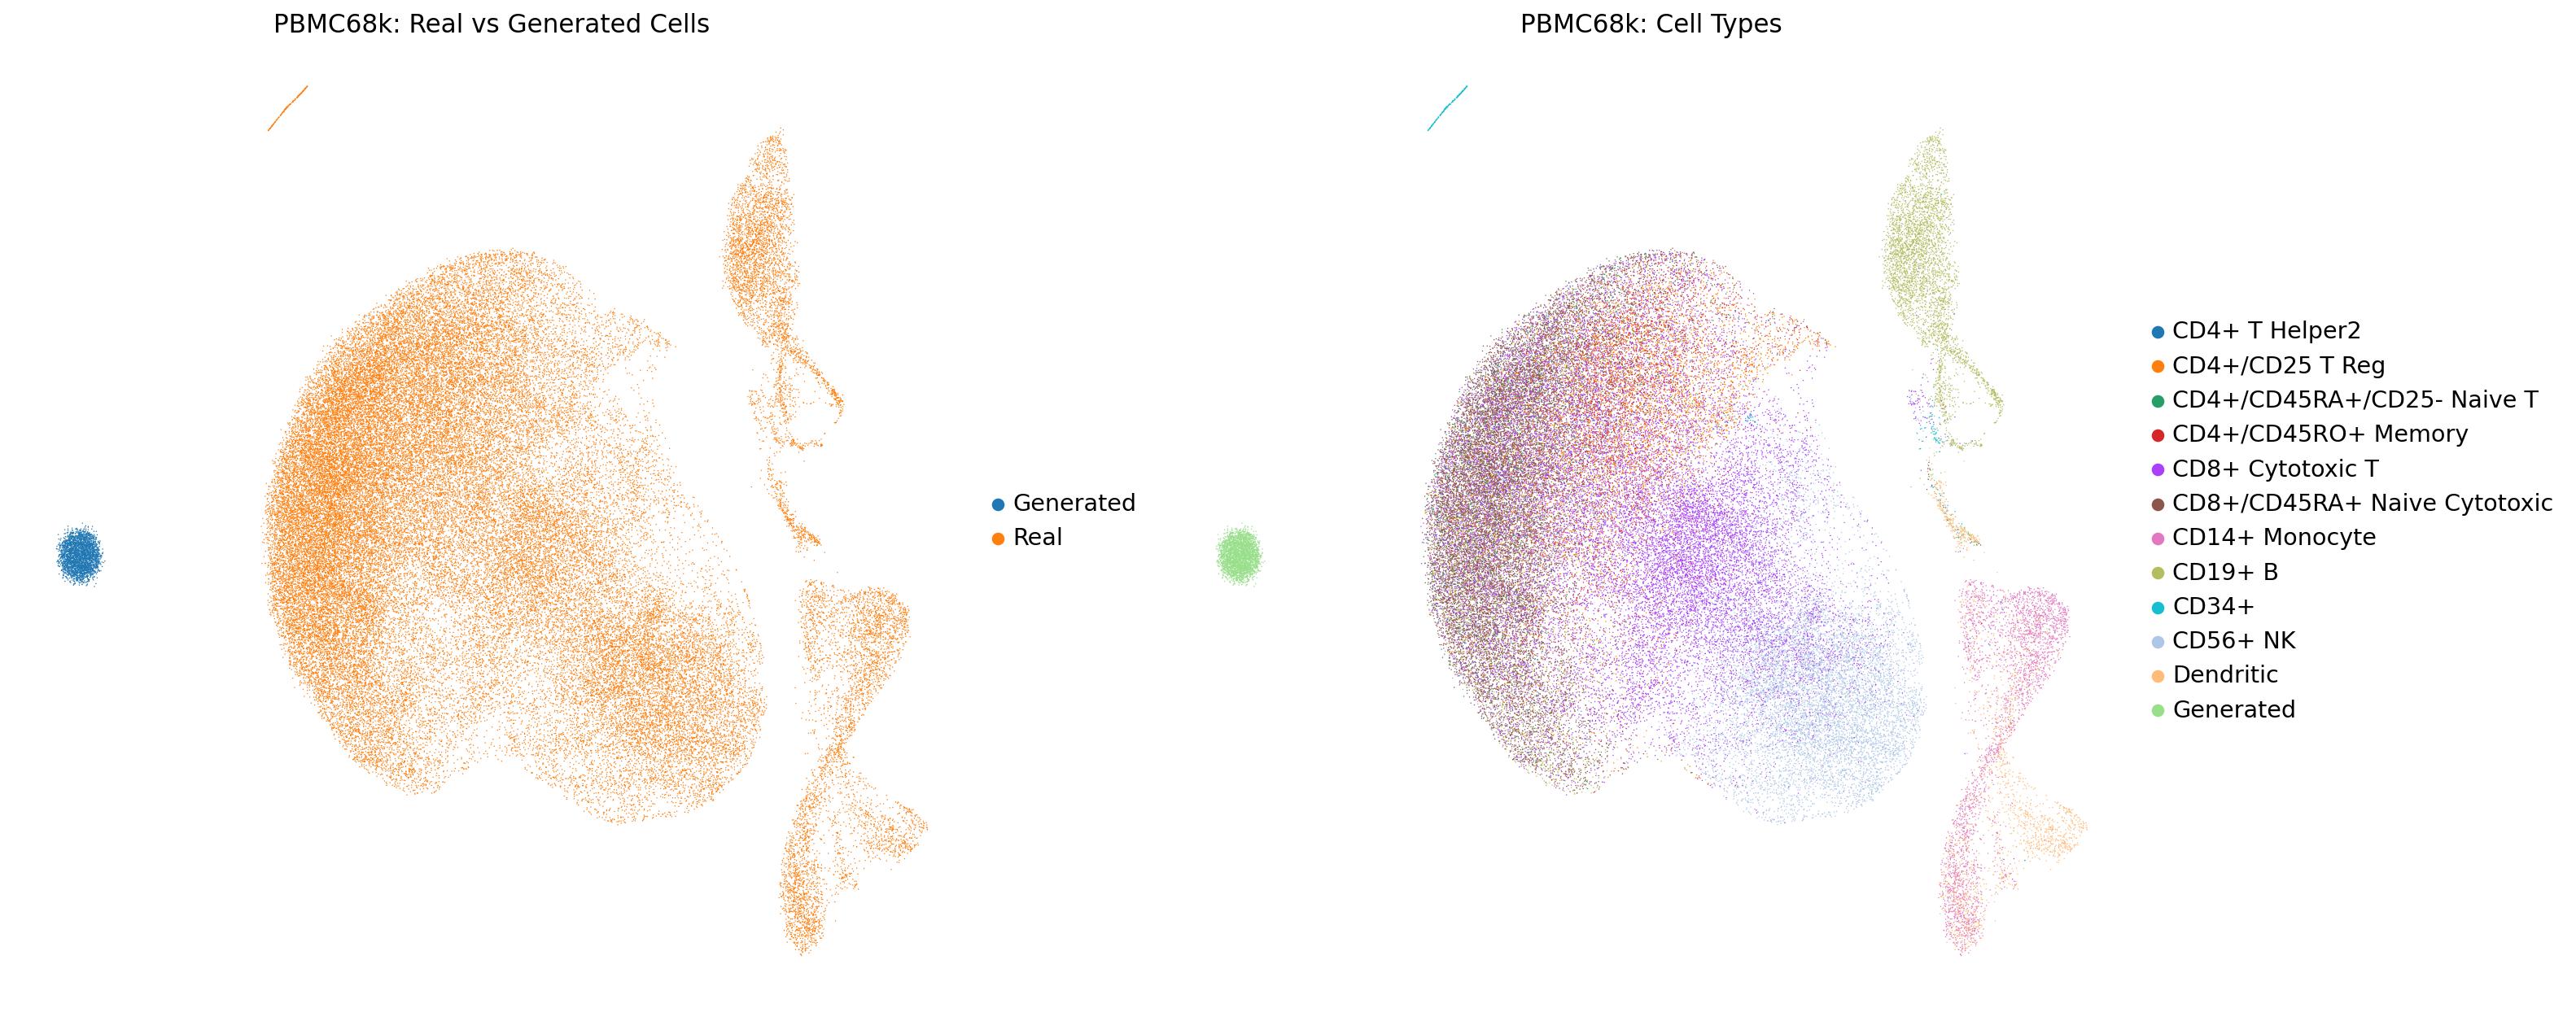

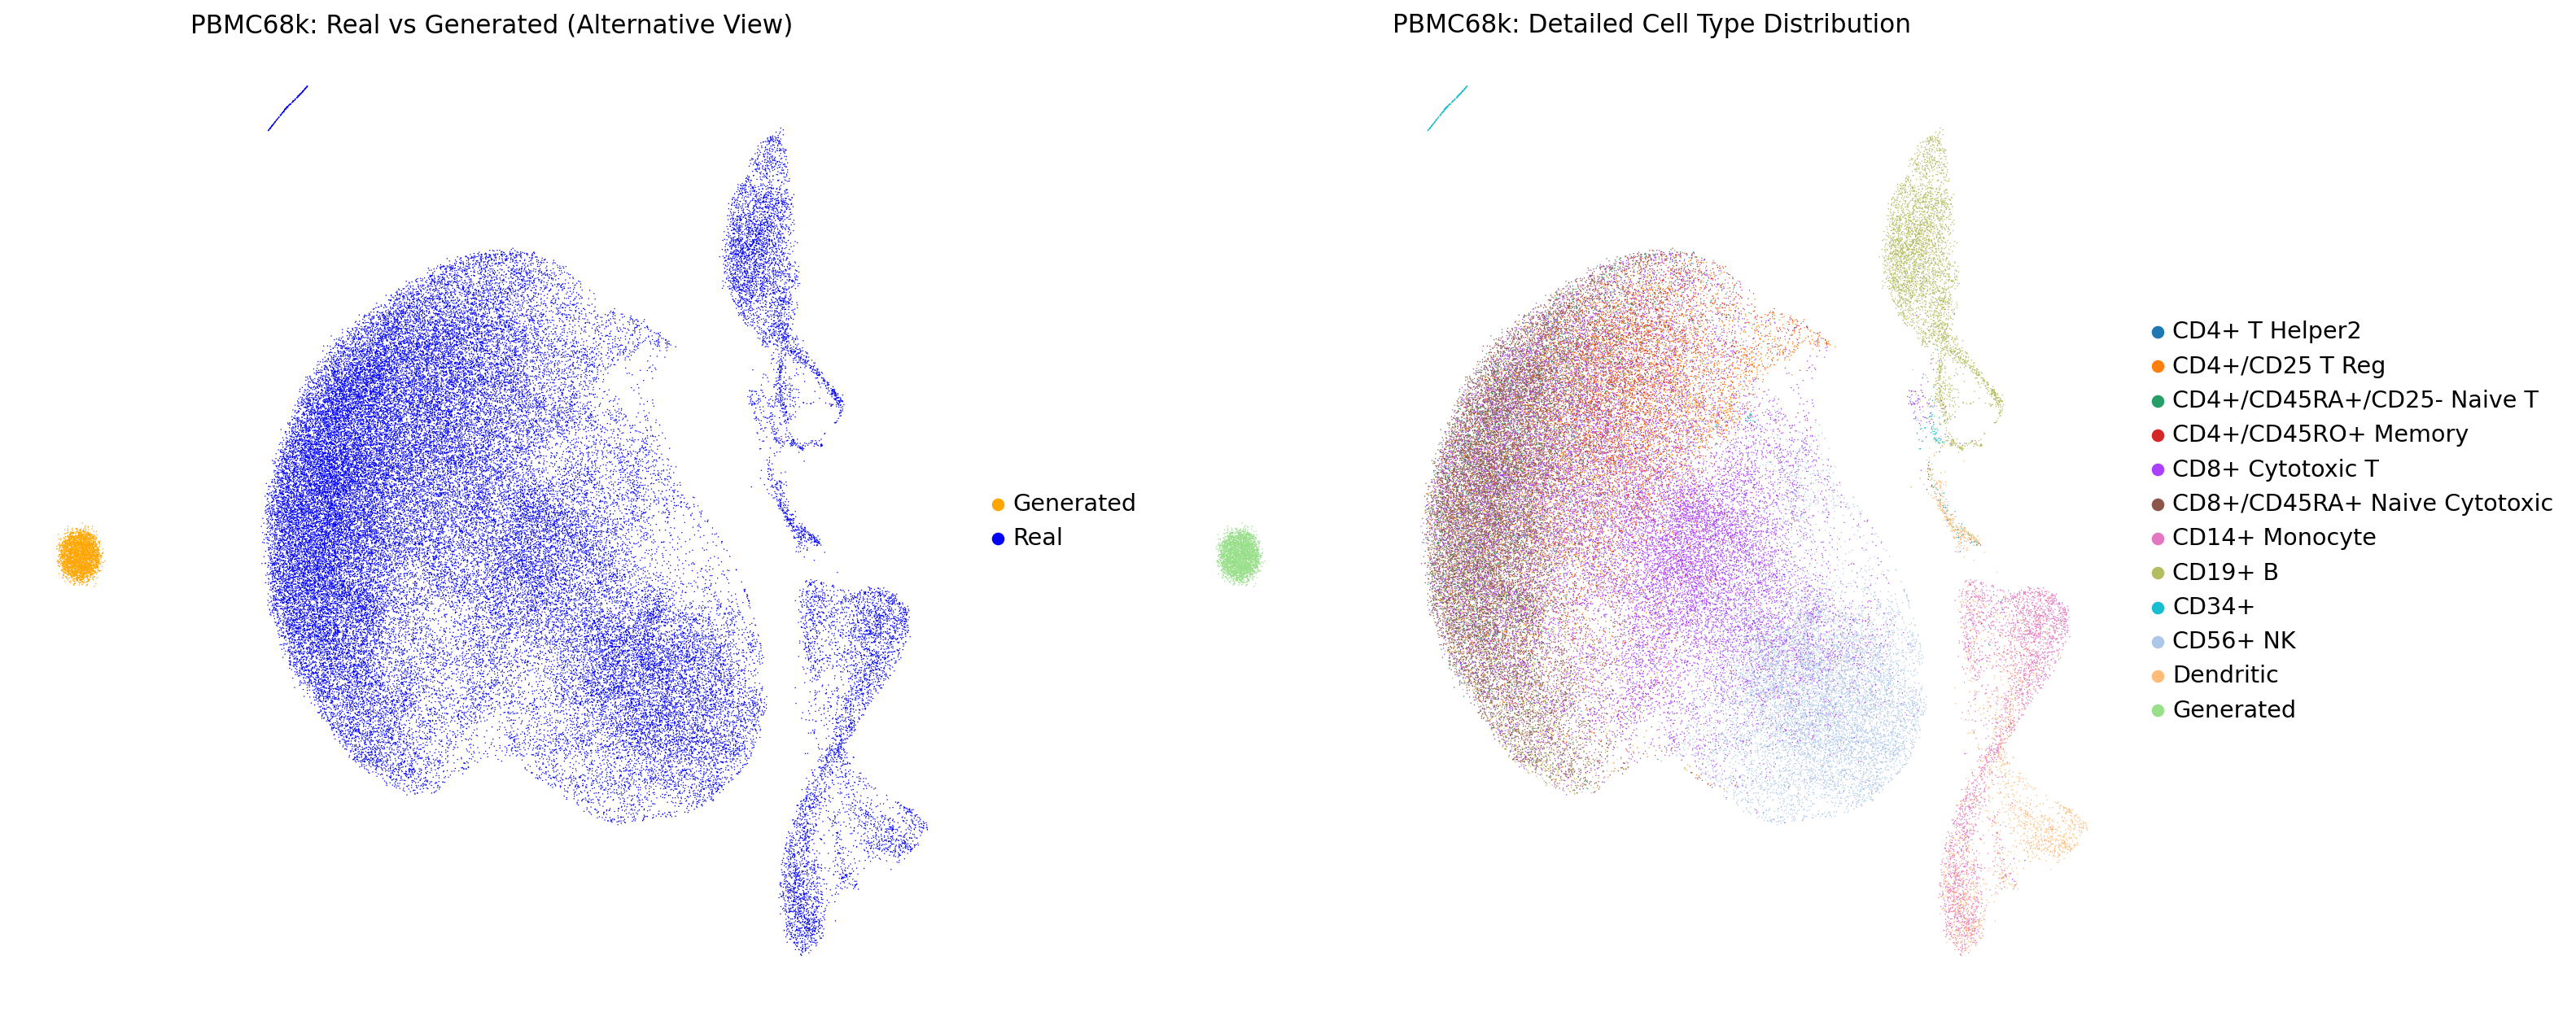

UMAP visualization completed!


In [10]:
if 'adata_combined' in locals() and 'X_umap' in adata_combined.obsm:
    print("Creating UMAP visualizations...")
    
    # Create UMAP plots
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    # Plot 1: Real vs Generated
    sc.pl.umap(adata_combined, 
               color='cell_origin', 
               ax=axes[0], 
               title='PBMC68k: Real vs Generated Cells', 
               frameon=False, 
               show=False)
    
    # Plot 2: Cell Types
    sc.pl.umap(adata_combined, 
               color='celltype', 
               ax=axes[1], 
               title='PBMC68k: Cell Types', 
               frameon=False, 
               show=False)
    
    plt.tight_layout()
    plt.show()
    
    # Alternative view with different color scheme
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    sc.pl.umap(adata_combined, 
               color='cell_origin', 
               palette=['orange', 'blue'], 
               ax=axes[0], 
               title='PBMC68k: Real vs Generated (Alternative View)', 
               frameon=False, 
               show=False)
    
    sc.pl.umap(adata_combined, 
               color='celltype', 
               ax=axes[1], 
               title='PBMC68k: Detailed Cell Type Distribution', 
               frameon=False, 
               show=False)
    
    plt.tight_layout()
    plt.show()
    
    print("UMAP visualization completed!")
else:
    print("UMAP results not available. Please run preprocessing first.")

## Individual Cell Type Comparisons

Creating individual cell type comparisons...


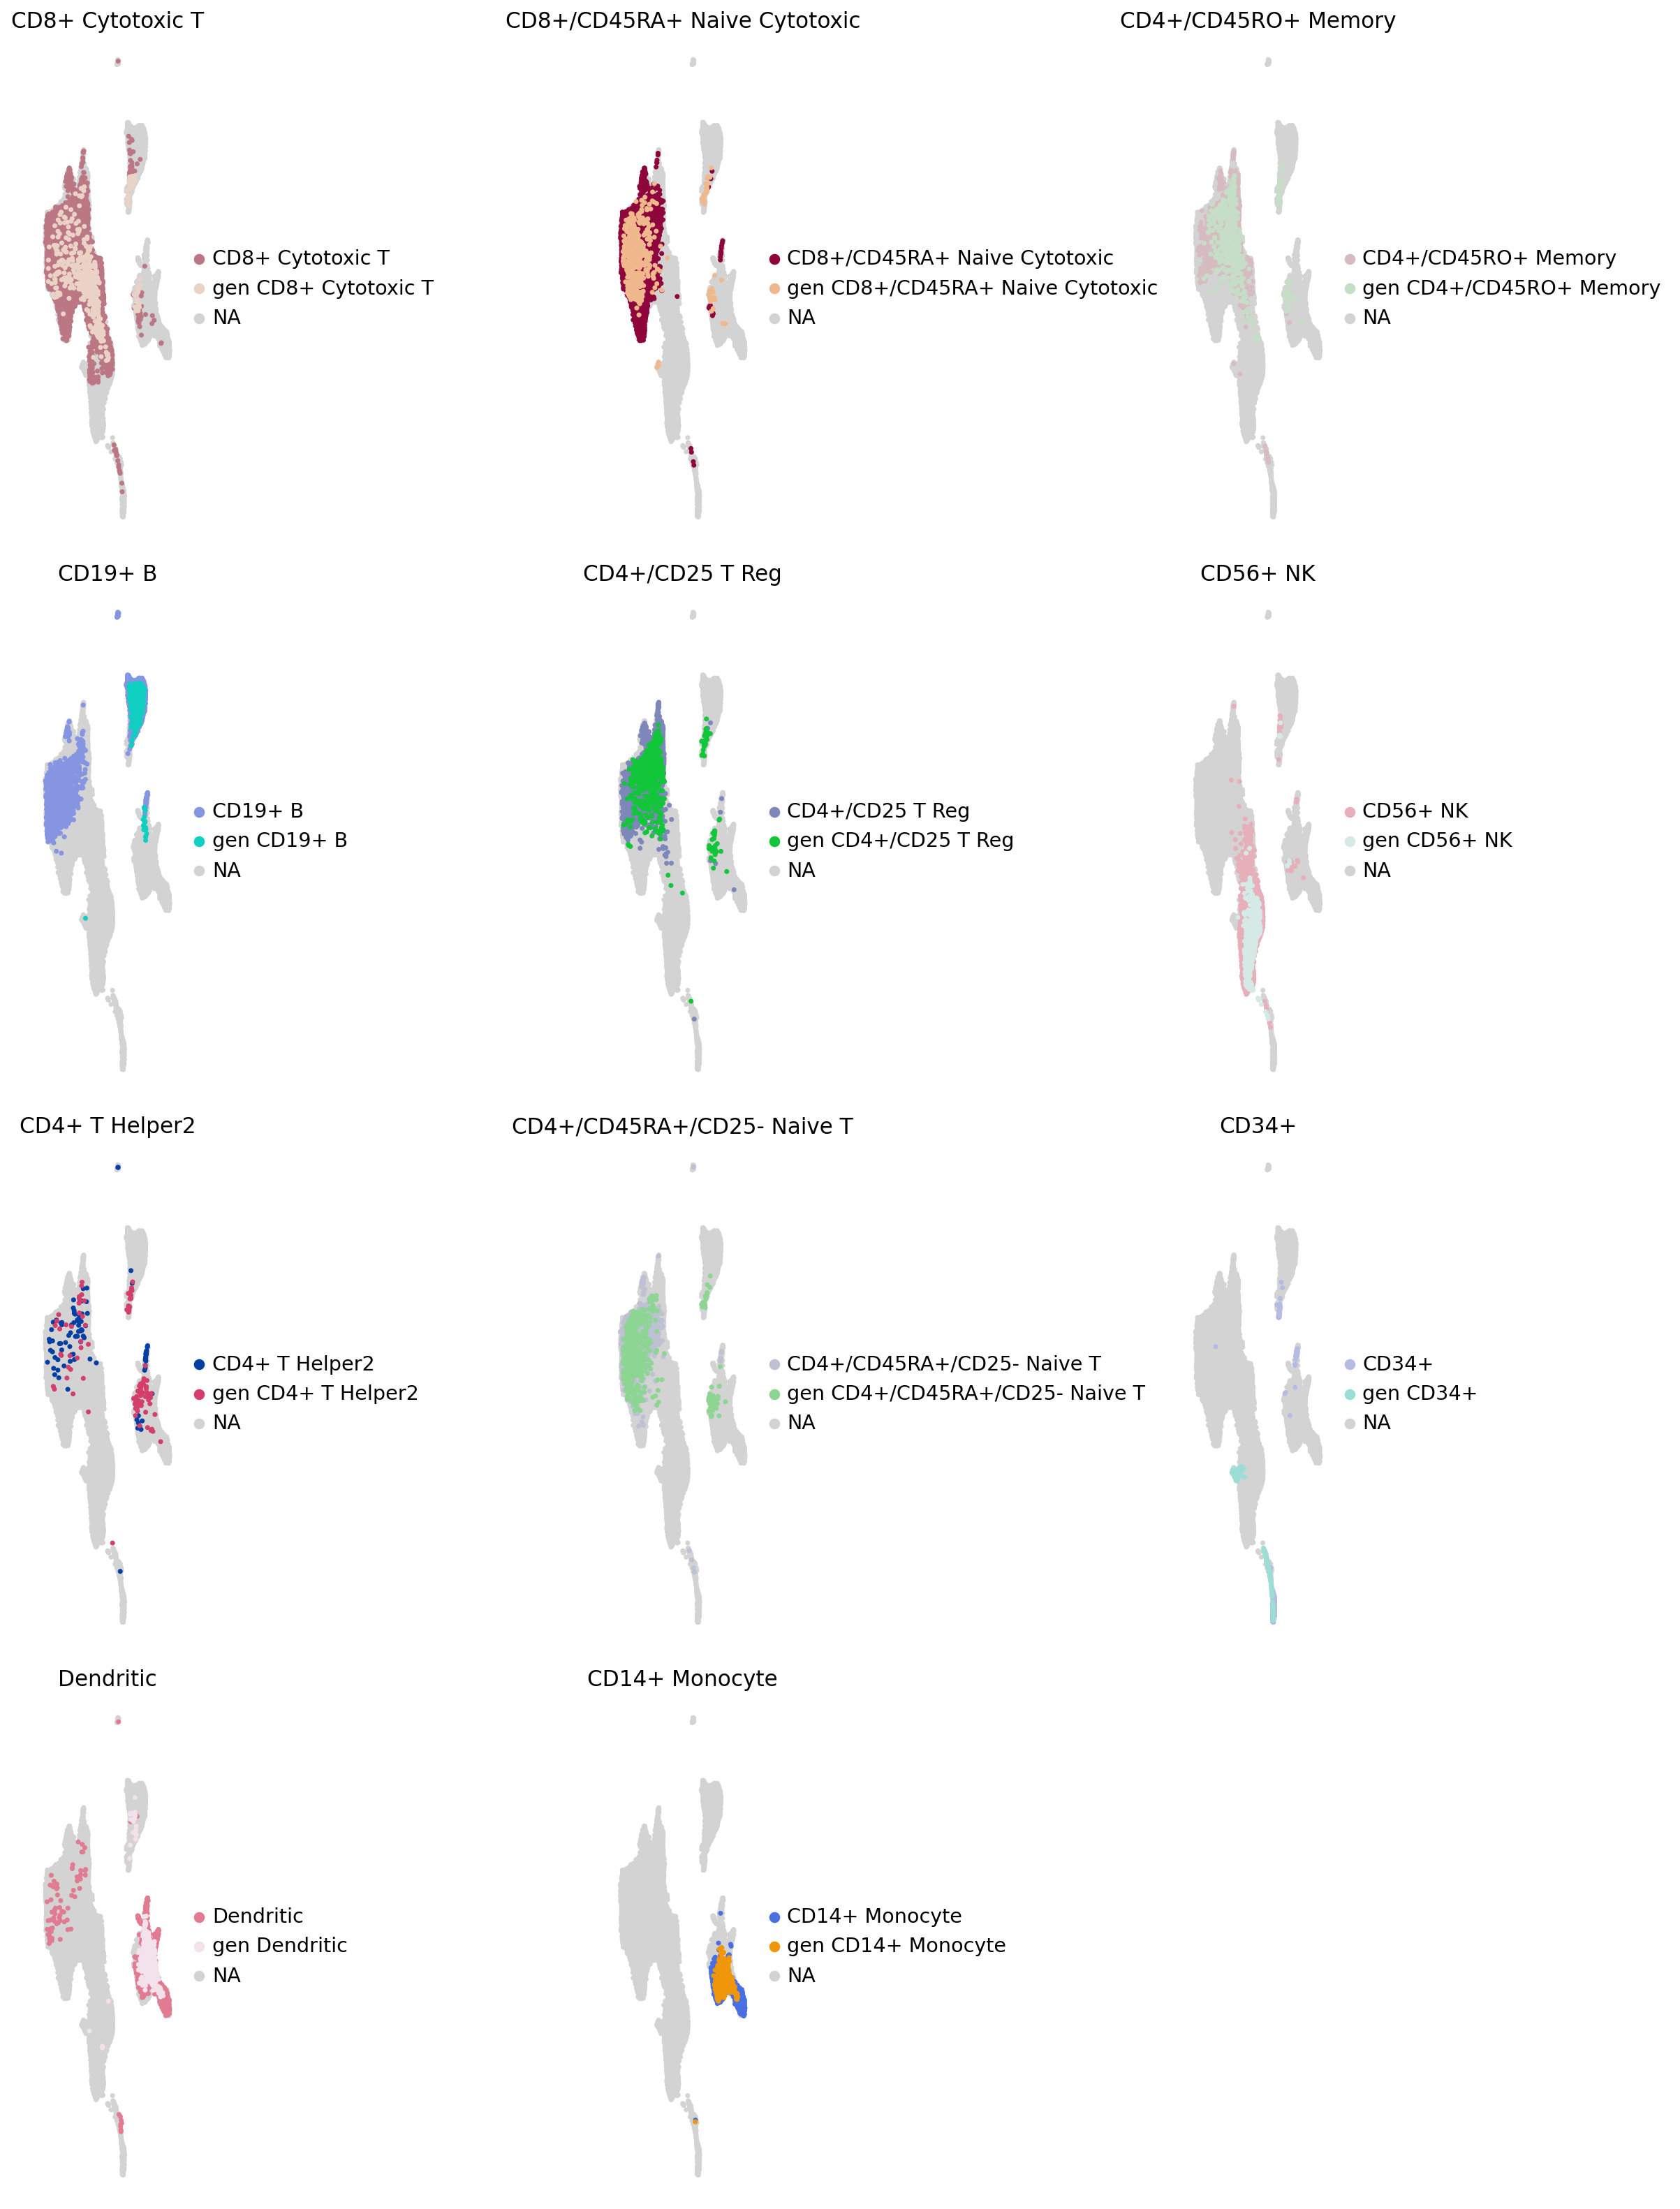

Individual plots created for 11 cell types


In [14]:
# Individual cell type comparisons for pancreas
if 'adata_combined' in locals() and 'celltype' in adata_combined.obs.columns and cell_gen_conditional is not None:
    print("Creating individual cell type comparisons...")
    
    # Get unique cell types from real data
    real_cell_types = [ct for ct in adata_combined.obs['celltype'].unique() if not ct.startswith('gen ')]
    
    # Create subplots
    n_types = len(real_cell_types)
    n_cols = 3
    n_rows = (n_types + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    
    for i, cell_type in enumerate(real_cell_types):
        row, col = i // n_cols, i % n_cols
        ax = axes[row, col]
        
        # Plot this cell type
        groups_to_show = [cell_type]
        if f'gen {cell_type}' in adata_combined.obs['celltype'].unique():
            groups_to_show.append(f'gen {cell_type}')
        
        try:
            sc.pl.umap(adata_combined, color="celltype", groups=groups_to_show, 
                      size=40, ax=ax, show=False, frameon=False, title=f'{cell_type}')
        except Exception as e:
            print(f"Warning: Could not plot {cell_type}: {e}")
            ax.text(0.5, 0.5, f'No data for\n{cell_type}', ha='center', va='center', 
                   transform=ax.transAxes)
    
    # Hide empty subplots
    for i in range(n_types, n_rows * n_cols):
        row, col = i // n_cols, i % n_cols
        axes[row, col].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Individual plots created for {len(real_cell_types)} cell types")
else:
    print("Cell type information not available for individual comparisons")
    if 'adata_combined' in locals():
        print("Available obs columns:", list(adata_combined.obs.columns))

In [15]:
adata_combined.obs["celltype"].unique()

['CD8+ Cytotoxic T', 'CD8+/CD45RA+ Naive Cytotoxic', 'CD4+/CD45RO+ Memory', 'CD19+ B', 'CD4+/CD25 T Reg', ..., 'gen CD4+/CD45RO+ Memory', 'gen CD56+ NK', 'gen CD8+ Cytotoxic T', 'gen CD8+/CD45RA+ Naive Cytotoxic', 'gen Dendritic']
Length: 22
Categories (22, object): ['CD4+ T Helper2', 'CD4+/CD25 T Reg', 'CD4+/CD45RA+/CD25- Naive T', 'CD4+/CD45RO+ Memory', ..., 'gen CD19+ B', 'gen CD34+', 'gen CD56+ NK', 'gen Dendritic']

Cells with 'gen' celltype: 4874
Cells without 'gen' celltype: 68579


Generated cells data shape: (4874, 1883)
Real cells data shape: (68579, 1883)


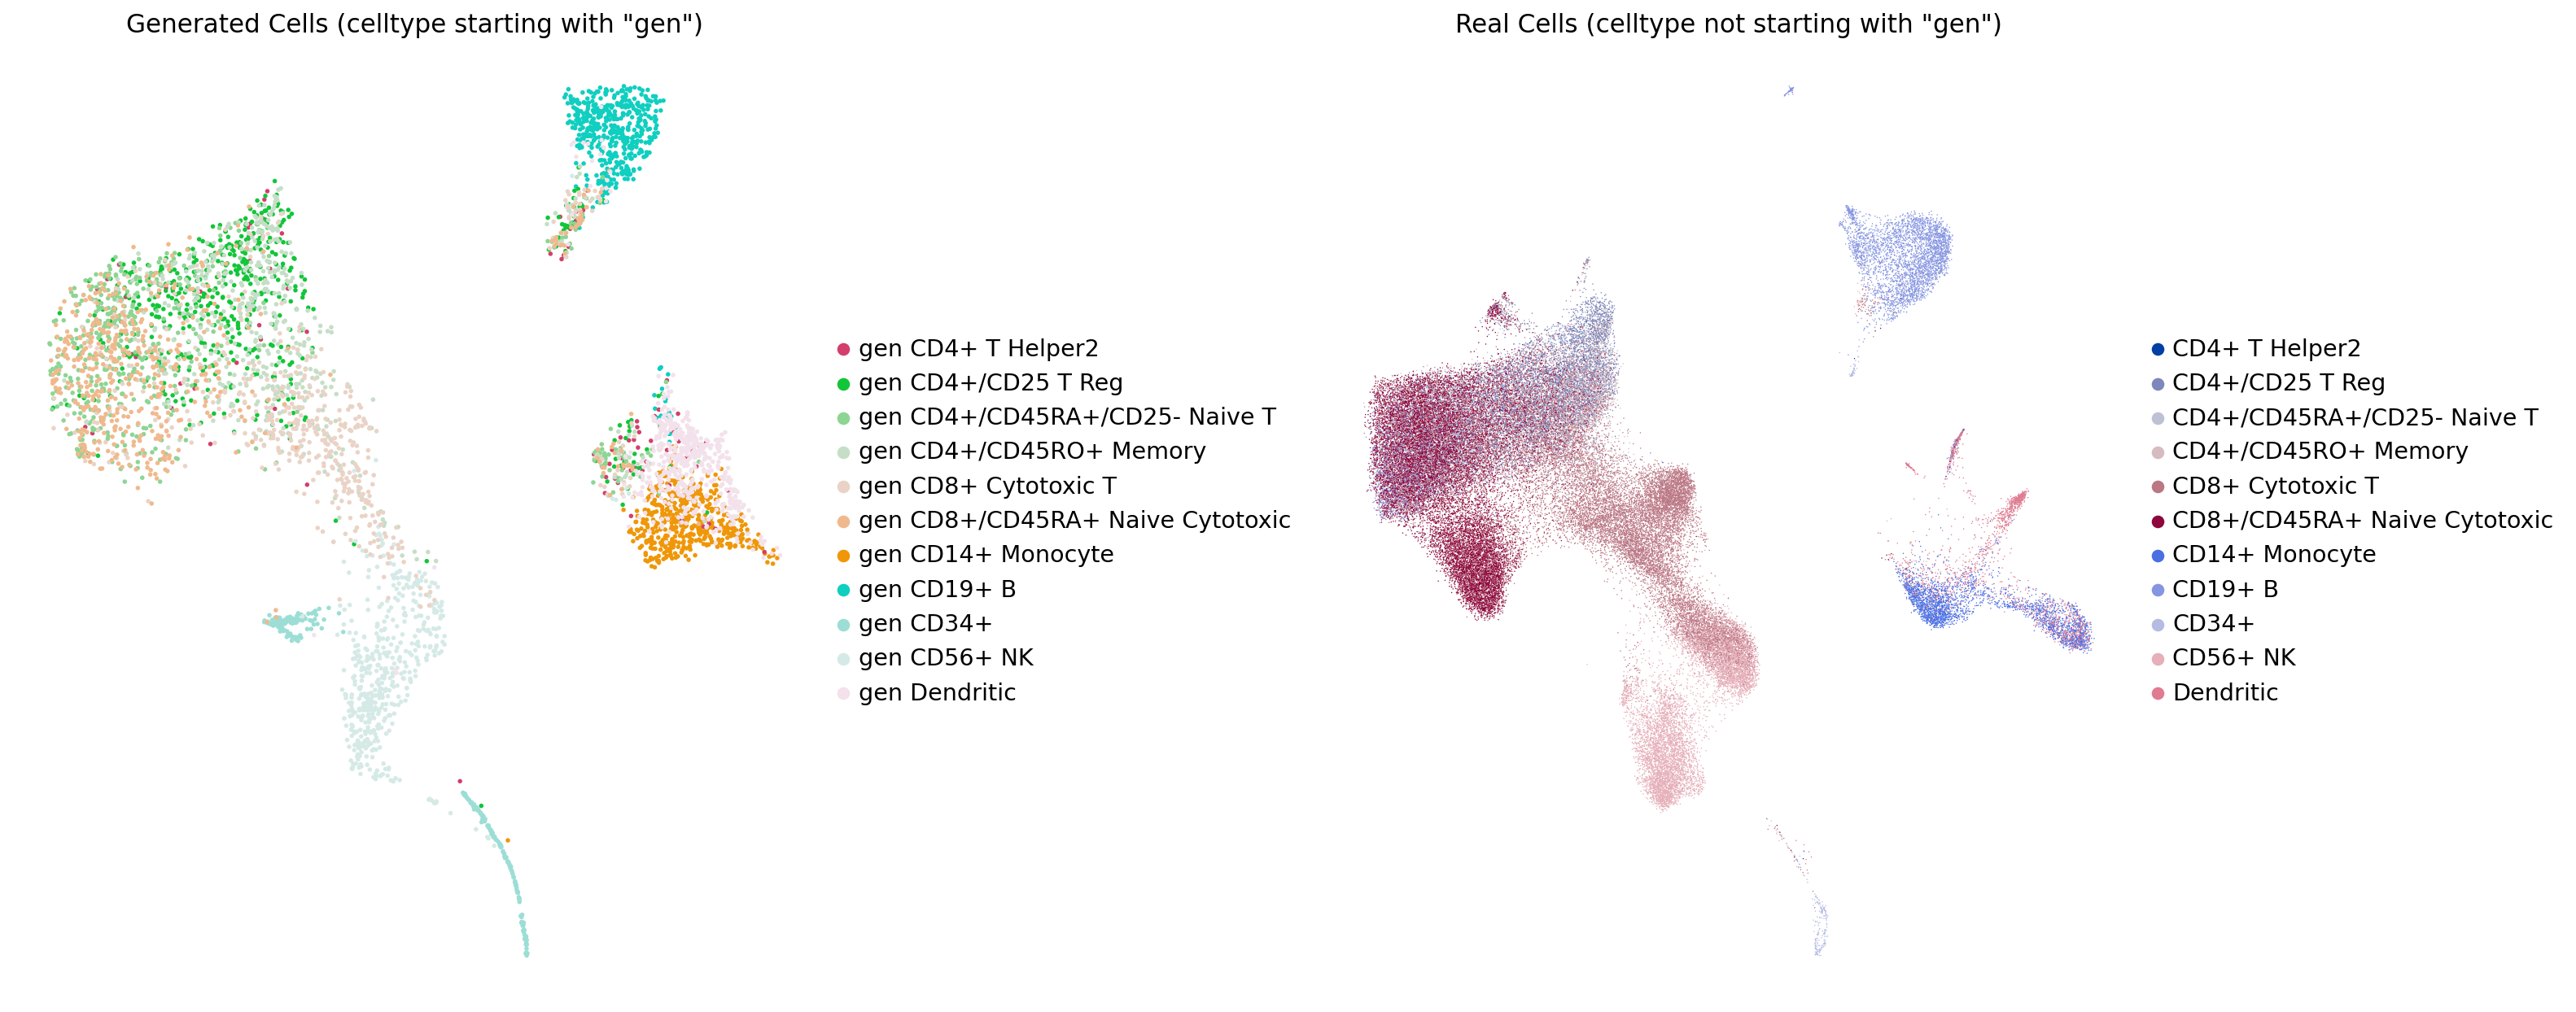

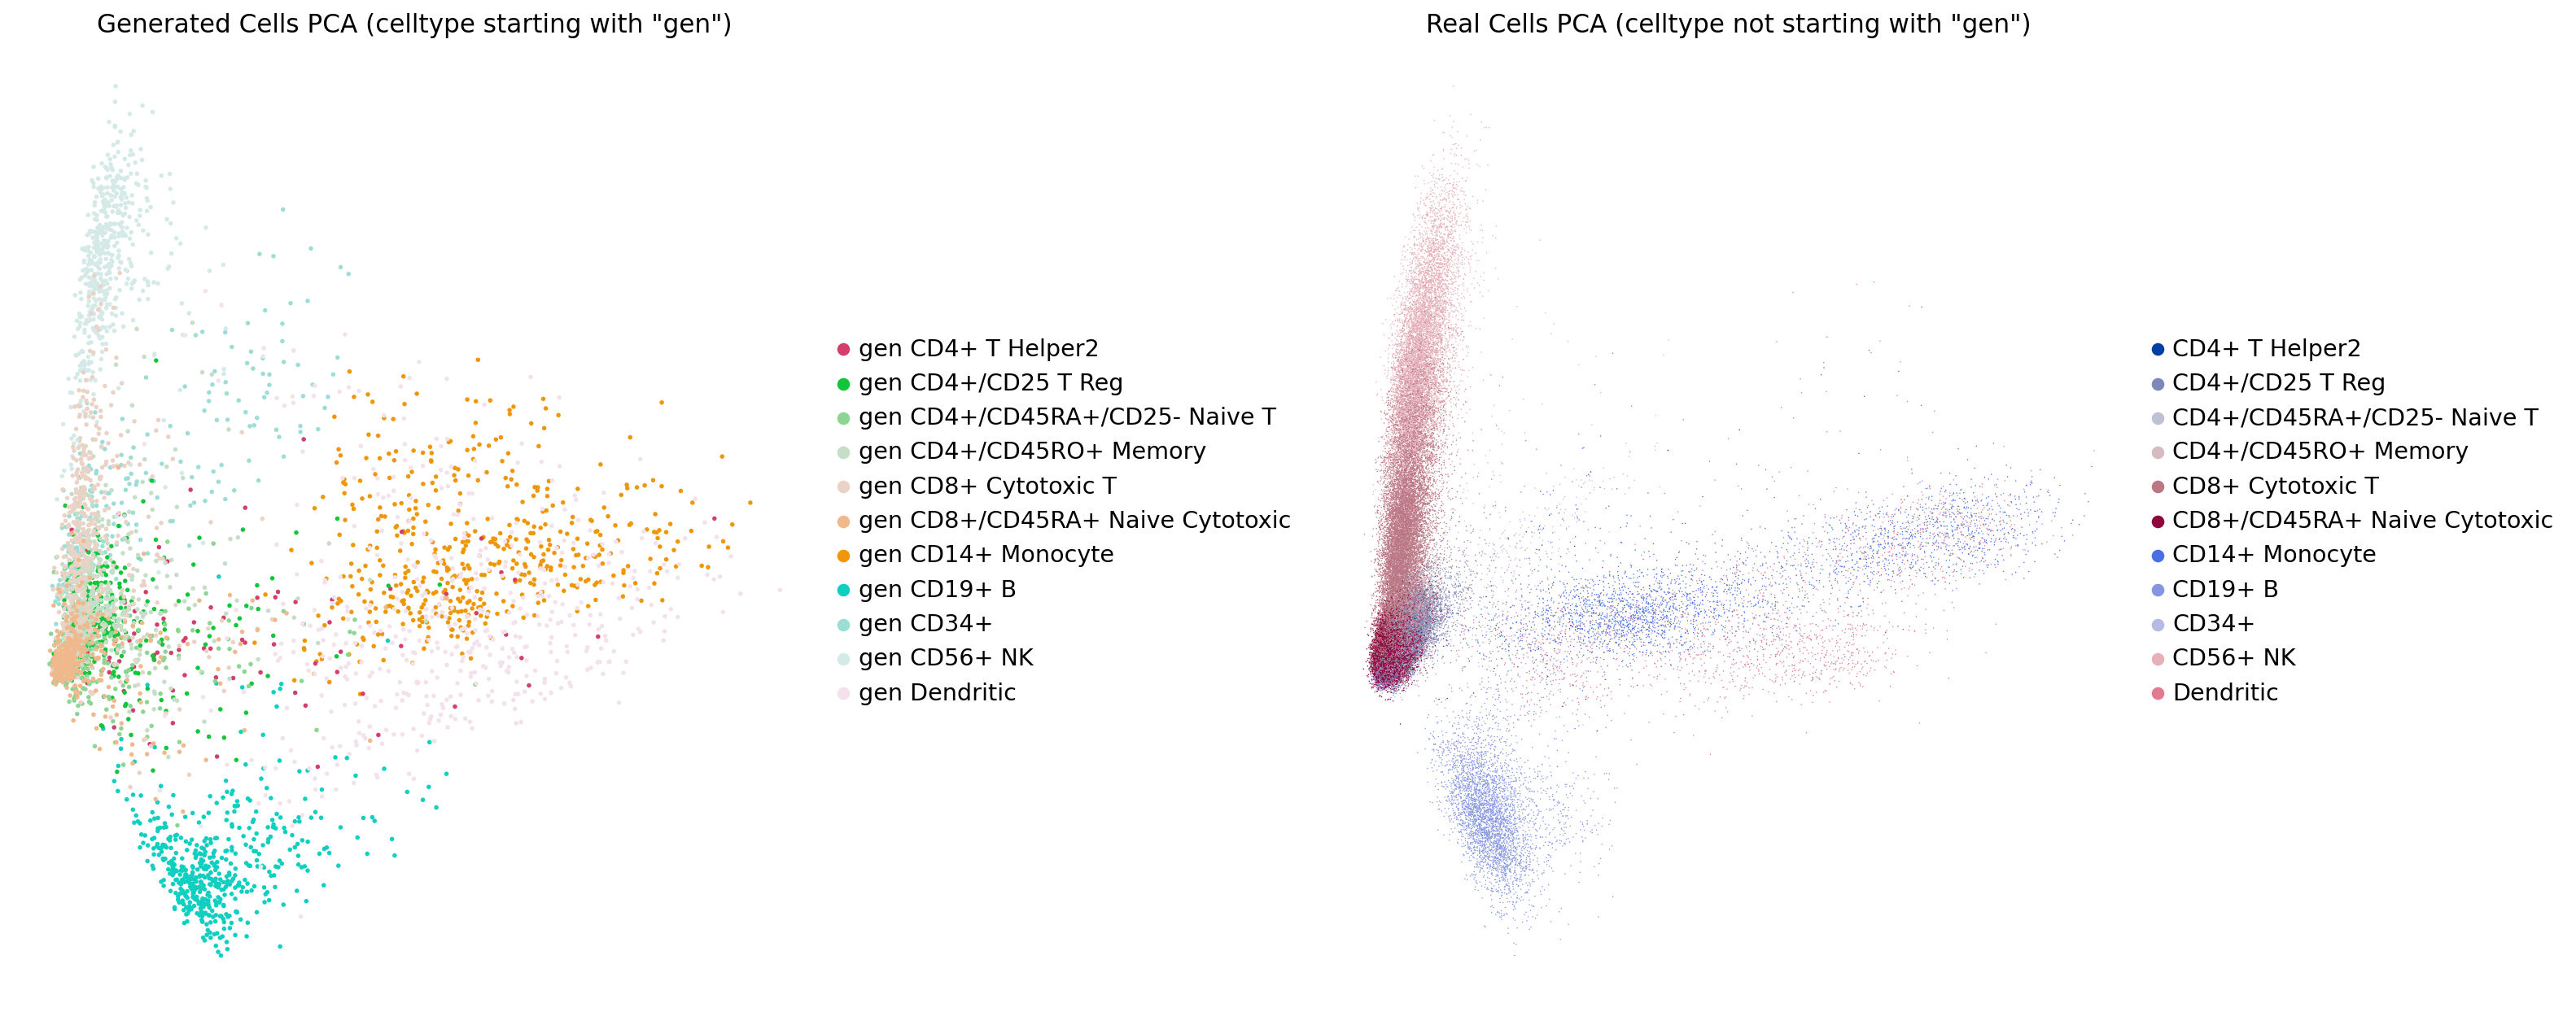

UMAP and PCA plots created for generated vs real cells!


In [16]:
# Separate cells based on whether celltype starts with "gen"
gen_mask = adata_combined.obs["celltype"].str.startswith("gen")
non_gen_mask = ~gen_mask

print(f"Cells with 'gen' celltype: {gen_mask.sum()}")
print(f"Cells without 'gen' celltype: {non_gen_mask.sum()}")

# Create separate AnnData objects
adata_gen = adata_combined[gen_mask].copy()
adata_non_gen = adata_combined[non_gen_mask].copy()

print(f"Generated cells data shape: {adata_gen.shape}")
print(f"Real cells data shape: {adata_non_gen.shape}")

# Create UMAP plots
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# UMAP for generated cells (starting with "gen")
sc.pl.umap(adata_gen, 
           color='celltype', 
           ax=axes[0], 
           title='Generated Cells (celltype starting with "gen")', 
           frameon=False, 
           show=False)

# UMAP for real cells (not starting with "gen")
sc.pl.umap(adata_non_gen, 
           color='celltype', 
           ax=axes[1], 
           title='Real Cells (celltype not starting with "gen")', 
           frameon=False, 
           show=False)

plt.tight_layout()
plt.show()

# Create PCA plots
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# PCA for generated cells (starting with "gen")
sc.pl.pca(adata_gen, 
          color='celltype', 
          ax=axes[0], 
          title='Generated Cells PCA (celltype starting with "gen")', 
          frameon=False, 
          show=False)

# PCA for real cells (not starting with "gen")
sc.pl.pca(adata_non_gen, 
          color='celltype', 
          ax=axes[1], 
          title='Real Cells PCA (celltype not starting with "gen")', 
          frameon=False, 
          show=False)

plt.tight_layout()
plt.show()

print("UMAP and PCA plots created for generated vs real cells!")

In [17]:
from itertools import chain

# ──────────────────────────────────────────────────────────
# 0. 前提: adata_combined には
#    obs["celltype"] = 〔実細胞クラスタ〕 ∪ 〔"gen " + 実クラスタ〕 が入っている
# ──────────────────────────────────────────────────────────

# ──────────────────────────────────────────────────────────
# 1. 実クラスタのみ取り出してマーカー遺伝子解析
# ──────────────────────────────────────────────────────────
is_real = ~adata_combined.obs["celltype"].str.startswith("gen")
adata_real = adata_combined[is_real].copy()   # ★ 解析対象は実細胞のみ

sc.tl.rank_genes_groups(
    adata_real,
    groupby      = "celltype",           # クラスタ列
    reference    = "rest",               # 各クラスタ vs. 残り全部
    method       = "wilcoxon",
    n_genes      = adata_real.shape[1]   # すべての遺伝子で検定
)

# ──────────────────────────────────────────────────────────
# 2. 各クラスタで P_adj < 0.001 かつ |logFC| が大きい
#    上位 20 遺伝子を抜き出し辞書にまとめる
# ──────────────────────────────────────────────────────────

marker_dict = {}                         # {cluster: [gene1, …, gene20]}
for clust in adata_real.obs["celltype"].cat.categories:
    df = sc.get.rank_genes_groups_df(adata_real, group=clust)              # 全遺伝子
    df["logfoldchanges_abs"] =df["logfoldchanges"].abs()
    df.sort_values("logfoldchanges_abs", ascending=False, inplace=True)  # |logFC| 降順
    df = df[df["pvals_adj"] < 0.05]                                       # P_adj < 0.001
                                                  # 上位
    top20 = df.head(20)["names"].tolist()
    marker_dict[clust] = top20
    print(clust)
    print(len(top20))
#==========================================================

"""
per‑cluster MATRIXPLOT (2×1: real / gen) を
カレントディレクトリ直下  cluster_plots/ に保存する
────────────────────────────────────────────
前提:
    • adata_combined : 実＋生成 AnnData
    • marker_dict    : {cluster_name: [top‑20 genes…]}  ← ①‑② で作成済み
"""

import os, re, scanpy as sc, matplotlib.pyplot as plt

# ───────────────────────────────────────────
# 0. 保存先ディレクトリを scanpy のデフォルトに設定
# ───────────────────────────────────────────
FIGDIR = os.path.join(os.getcwd(), "cluster_plots")
os.makedirs(FIGDIR, exist_ok=True)
sc.settings.figdir = FIGDIR          # save= の既定出力先

def sanitize(name: str) -> str:
    """ファイル名に使えない文字を _ に置換"""
    return re.sub(r"[^\w\-]", "_", name)

# パラメータ
GENES_PER_CLUSTER = 20
real_clusters     = list(marker_dict.keys())

# ───────────────────────────────────────────
# 1. 各クラスタで 2×1 subplot を作成
# ───────────────────────────────────────────
for clust in real_clusters:
    gen_label = f"gen {clust}"
    genes_all = marker_dict[clust][:GENES_PER_CLUSTER]

    # ── Figure / Axes 作成 ───────────────────────────
    fig, axes = plt.subplots(
        nrows   = 2, ncols = 1,
        figsize = (8, 6),
        sharex  = False, sharey=False
    )

    # ── 0 行目: real sample ──────────────────────────
    sc.pl.matrixplot(
        adata_combined[is_real],
        var_names      = genes_all,
        groupby        = "celltype",
        cmap           = "bwr",
        standard_scale = "var",
        dendrogram     = False,
        swap_axes      = False,          # 列＝遺伝子・行＝celltype(=1 行)
        show           = False,
        ax             = axes[0],        # ← subplot 指定
    )

    # ── 1 行目: generated sample ─────────────────────
    sc.pl.matrixplot(
        adata_combined[~is_real],
        var_names      = genes_all,
        groupby        = "celltype",
        cmap           = "bwr",
        standard_scale = "var",
        dendrogram     = False,
        swap_axes      = False,
        show           = False,
        ax             = axes[1],
    )

    plt.tight_layout(h_pad=1.2)
    save_path = os.path.join(FIGDIR, f"{sanitize(clust)}_dual_matrixplot.png")
    fig.savefig(save_path, dpi=300)
    plt.close(fig)

    print(f"✔  saved {save_path}")

print(f"✔  全クラスタの図を {FIGDIR} に保存しました。")



ranking genes


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:01:35)
CD4+ T Helper2
1
CD4+/CD25 T Reg
20
CD4+/CD45RA+/CD25- Naive T
20
CD4+/CD45RO+ Memory
20
CD8+ Cytotoxic T
20
CD8+/CD45RA+ Naive Cytotoxic
20
CD14+ Monocyte
20
CD19+ B
20
CD34+
20
CD56+ NK
20
Dendritic
20
✔  saved /home/suzuki/Projects/scDiffusion/exp_script/pbmc68k_GRN1/cluster_plots/CD4__T_Helper2_dual_matrixplot.png
✔  saved /home/suzuki/Projects/scDiffusion/exp_script/pbmc68k_GRN1/cluster_plots/CD4__CD25_T_Reg_dual_matrixplot.png
✔  saved /home/suzuki/Projects/scDiffusion/exp_script/pbmc68k_GRN1/cluster_plots/CD4__CD45RA__CD25-_Naive_T_dual_matrixplot.png
✔  saved /home/suzuki/Projects/scDiffusion/exp_script/pbmc68k_GRN

In [18]:
adata_real

AnnData object with n_obs × n_vars = 68579 × 1883
    obs: 'cell_origin', 'celltype'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'pca', 'neighbors', 'umap', 'cell_origin_colors', 'celltype_colors', 'rank_genes_groups'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [19]:
adata_gen

AnnData object with n_obs × n_vars = 4874 × 1883
    obs: 'cell_origin', 'celltype'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'pca', 'neighbors', 'umap', 'cell_origin_colors', 'celltype_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [29]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import igraph as ig

# 1) adata → 重み付きグラフ（頂点に embedding を保存）
def make_weighted_graph_from_adata(adata, n_components=50):
    X = adata.X.toarray() if hasattr(adata.X, "toarray") else adata.X   # (cells × genes)
    genes = np.array(adata.var_names)
    Xt = X.T  # (genes × cells)

    pca = PCA(n_components=n_components)
    emb = pca.fit_transform(Xt)   # (genes × 50)

    sim = cosine_similarity(emb)  # 類似度を重みとして使う（[-1,1]）

    g = ig.Graph.Weighted_Adjacency(sim.tolist(), mode="undirected", attr="weight", loops=False)
    g.vs["name"] = genes.tolist()
    # ← これが無いと後で KeyError になる
    g.vs["embedding"] = [e.tolist() for e in emb]

    return g

# 2) 2グラフの埋め込み類似度（共通遺伝子に揃えて平均コサイン）
def graph_embedding_similarity(g1, g2):
    # gene名で対応付け
    names1 = np.array(g1.vs["name"]); names2 = np.array(g2.vs["name"])
    common = np.intersect1d(names1, names2)
    if common.size == 0:
        raise ValueError("共通遺伝子がありません。")

    # 頂点順に注意：名前→インデックスの辞書で揃える
    idx1 = [g1.vs.find(name=n).index for n in common]
    idx2 = [g2.vs.find(name=n).index for n in common]

    emb1 = np.array(g1.vs["embedding"])[idx1]
    emb2 = np.array(g2.vs["embedding"])[idx2]

    # 共通遺伝子間で対応する行同士のコサインを平均
    # （別案：全対全コサインの平均/Top-k 平均なども可）
    num = np.sum(emb1 * emb2, axis=1)
    den = (np.linalg.norm(emb1, axis=1) * np.linalg.norm(emb2, axis=1) + 1e-12)
    per_gene_cos = num / den
    return float(np.mean(per_gene_cos))

# 3) 2グラフを共通遺伝子に揃えてLeiden→クラスタ一致度（ARI/NMI）
def compare_graphs_by_communities(g1, g2, resolution=1.0):
    # 共通遺伝子にサブグラフ化（順序を明示的に合わせる）
    names1 = np.array(g1.vs["name"]); names2 = np.array(g2.vs["name"])
    common = np.intersect1d(names1, names2)
    if common.size == 0:
        raise ValueError("共通遺伝子がありません。")

    # g1, g2 ともに common の順に頂点を並べ替え
    g1_sub = g1.subgraph([g1.vs.find(name=n).index for n in common])
    g2_sub = g2.subgraph([g2.vs.find(name=n).index for n in common])

    # Leiden（重み使用）
    c1 = g1_sub.community_leiden(weights="weight", resolution_parameter=resolution)
    c2 = g2_sub.community_leiden(weights="weight", resolution_parameter=resolution)

    labels1 = c1.membership
    labels2 = c2.membership

    # 一致度
    ari = adjusted_rand_score(labels1, labels2)
    nmi = normalized_mutual_info_score(labels1, labels2)

    return {
        "genes": common,            # 比較に使った遺伝子順
        "partition1": c1,           # igraph.VertexClustering
        "partition2": c2,           # igraph.VertexClustering
        "ari": float(ari),
        "nmi": float(nmi),
    }


In [30]:
g_real = make_weighted_graph_from_adata(adata_real, n_components=50)
g_gen  = make_weighted_graph_from_adata(adata_gen,  n_components=50)

# 埋め込みレベルの近さ（共通遺伝子で平均コサイン）
sim_score = graph_embedding_similarity(g_real, g_gen)
print("Embedding similarity (mean cosine):", sim_score)

# コミュニティ（Leiden）一致度
res = compare_graphs_by_communities(g_real, g_gen, resolution=1.0)
print("ARI:", res["ari"], "NMI:", res["nmi"], "#genes:", len(res["genes"]))


Embedding similarity (mean cosine): 0.29550960619073724
ARI: 1.0 NMI: 1.0 #genes: 1883
